In [1]:
!pip install bertviz
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
from bertviz import head_view

text = "write a short introduction about the US capital city"
model_name = "Qwen/Qwen2.5-0.5B"
tokenizer = AutoTokenizer.from_pretrained(model_name, output_attentions=True)
model = AutoModelForCausalLM.from_pretrained(model_name, output_attentions=True).eval().cuda()



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.7 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

In [2]:
# Tokenize input
inputs = tokenizer(text, return_tensors="pt").to(model.device)

In [3]:
# Generate outputs with attention
with torch.no_grad():
   outputs = model(**inputs, output_attentions=True)
# Get attention weights
attention = outputs.attentions

In [5]:
len(attention)

24

In [6]:
# Use bertviz and attention weights to visualize
# the relations between the input tokens
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
head_view(attention, tokens)

<IPython.core.display.Javascript object>

In [7]:
import torch
import gc
import time

# Unload models and clean up gpu memory cache
def free_gpu(model):
  if model:
    # Removes the reference to the model's memory,
    # making it eligible for garbage collection.
    del model

  # Release any cached GPU memory that's no longer needed.
  torch.cuda.empty_cache()

  # Trigger garbage collection to ensure memory is fully released.
  gc.collect()

Run LLM with hf

In [8]:

from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# Initialize the text generation pipeline
generator = pipeline('text-generation', model='Qwen/Qwen2.5-0.5B')

# Define your prompt
prompt = "Write a short introduction about US capital city."

# Generate text
generated_text = generator(prompt, max_length=50, num_return_sequences=1)

# Print the generated text
print(generated_text[0]['generated_text'])

free_gpu(generator.model)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Write a short introduction about US capital city. Capital city of the United States is Washington DC.


Let's break it up the generator function to examine step by step.

In [9]:
import torch
import time
from transformers import AutoTokenizer, AutoModelForCausalLM

first_token_generated = False

# (1) Specify the model and load tokenizer and model
model_name = "Qwen/Qwen2.5-0.5B"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(model_name, trust_remote_code=True).to("cuda" if torch.cuda.is_available() else "cpu")

# (2) Define the input prompt - a text about communication history
prompt = """The history of human communication is a story of innovation. From ancient cave paintings and
spoken language to the invention of writing systems, humans have constantly developed new methods to express ideas and share knowledge. The printing press revolutionized the spread of information, enabling books to be produced and distributed at an unprecedented scale. Centuries later, the invention of the telegraph, radio, and television further transformed how we connect with one another. But perhaps no advancement has reshaped communication more profoundly than the internet.
Today, digital platforms allow billions of people to share messages, media, and experiences in real time.
Social media, messaging apps, and video conferencing have broken down geographical barriers and created
new ways of building communities. At the same time, these technologies raise important questions about
privacy, information overload, and the nature of human interaction.
Looking ahead, emerging technologies such as virtual reality, brain-computer interfaces, and artificial
 intelligence promise to once again redefine how we communicate. As we reflect on this history and
 anticipate the future, one question arises:

How might the next wave of communication tools shape our relationships, societies, and sense of identity?"""

# (3) Convert (Tokenize) prompt to the input format that model understands
max_new_tokens = 100
# tokenize the input prompt for the first output token
# PS: prompt is the initial input sequence for LLM generation
idx = tokenizer(prompt, return_tensors="pt").input_ids.to(model.device)
start_time = total_time = time.time()
times = []

# (4) Main generation loop - generate tokens one by one
for _ in range(max_new_tokens):

    # (A) Set the current context for generation
    idx_cond = idx
    with torch.no_grad():
        # (B) Generate predictions (token candidates) for next token
        outputs = model(idx_cond)
        # Get the logits (raw prediction scores) for each token predictions
        logits = outputs.logits

    # (C) Select next token from the predictions generated in step (B)
    logits = logits[:, -1, :] #  Select only the logits for the last token
    probas = torch.softmax(logits, dim=-1) # Convert logits to probabilities using softmax
    # Sample the next token from the probability distribution of the predicted tokens from step (B)
    idx_next = torch.multinomial(probas, num_samples=1)
    print("Next Token is:", tokenizer.decode(idx_next[0], skip_special_tokens=True))
    time_cost = time.time() - start_time
    times.append(time_cost)

    # Track time spent in token generation
    if not first_token_generated:
        print(f"Time taken for generating the first token: {time_cost:.4f} seconds")
        first_token_generated = True
    else:
        print(f"Time taken for generating a token: {time_cost:.4f} seconds")

    start_time = time.time()

    # (D) Append the new token to the input sequence
    idx = torch.cat((idx, idx_next), dim=1)

    # (E) Check if end-of-sequence token was generated
    if idx_next.item() == tokenizer.eos_token_id:
        print("\n[Generation completed - EOS token reached]")
        break

# Decode the entire generated sequence
generated_text = tokenizer.decode(idx[0], skip_special_tokens=True)
print(f"Total time take for next token: {time.time() - total_time:.4f} seconds")
print(generated_text)

# Free GPU memory
free_gpu(model=model)


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Next Token is:  Let
Time taken for generating the first token: 0.2333 seconds
Next Token is: 's
Time taken for generating a token: 0.1477 seconds
Next Token is:  explore
Time taken for generating a token: 0.1344 seconds
Next Token is:  this
Time taken for generating a token: 0.1224 seconds
Next Token is:  question
Time taken for generating a token: 0.1245 seconds
Next Token is:  further
Time taken for generating a token: 0.1235 seconds
Next Token is:  in
Time taken for generating a token: 0.1291 seconds
Next Token is:  our
Time taken for generating a token: 0.1263 seconds
Next Token is:  discussion
Time taken for generating a token: 0.1255 seconds
Next Token is:  of
Time taken for generating a token: 0.1260 seconds
Next Token is:  "
Time taken for generating a token: 0.1279 seconds
Next Token is: Today
Time taken for generating a token: 0.1271 seconds
Next Token is:  is
Time taken for generating a token: 0.1269 seconds
Next Token is:  Today
Time taken for generating a token: 0.1246 sec

Text(0.5, 1.0, 'LLM Generation Times for each token')

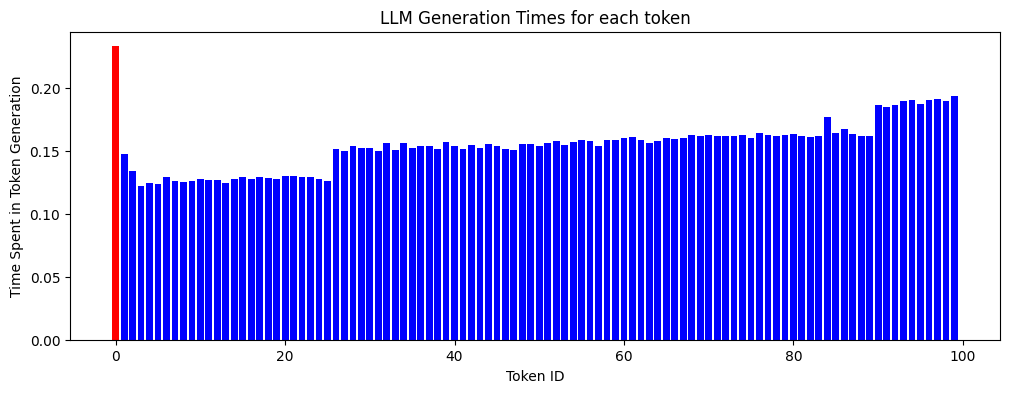

In [10]:
import matplotlib.pyplot as plt

# First chart: First bar red, others blue
plt.figure(figsize=(12, 4))
# plt.subplot(1, 2, 1)
plt.bar(range(len(times)), times, color=['red'] + ['blue'] * (len(times) - 1))
plt.xlabel("Token ID")
plt.ylabel("Time Spent in Token Generation")
plt.title("LLM Generation Times for each token")

In [11]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "Qwen/Qwen2.5-0.5B"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(model_name, trust_remote_code=True, use_cache=True) \
            .to("cuda" if torch.cuda.is_available() else "cpu")

model_name = "Qwen/Qwen2.5-0.5B"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(model_name, trust_remote_code=True).to("cuda" if torch.cuda.is_available() else "cpu")

prompt = """The history of human communication is a story of innovation. From ancient cave paintings and spoken language to the invention of writing systems, humans have constantly developed new methods to express ideas and share knowledge. The printing press revolutionized the spread of information, enabling books to be produced and distributed at an unprecedented scale. Centuries later, the invention of the telegraph, radio, and television further transformed how we connect with one another. But perhaps no advancement has reshaped communication more profoundly than the internet.
Today, digital platforms allow billions of people to share messages, media, and experiences in real time. Social media, messaging apps, and video conferencing have broken down geographical barriers and created new ways of building communities. At the same time, these technologies raise important questions about privacy, information overload, and the nature of human interaction.
Looking ahead, emerging technologies such as virtual reality, brain-computer interfaces, and artificial intelligence promise to once again redefine how we communicate. As we reflect on this history and anticipate the future, one question arises:

How might the next wave of communication tools shape our relationships, societies, and sense of identity?"""

num_interations = 100
times_with_cache = []

first_token_generated = False
input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(model.device)
idx = input_ids
start_time = total_time = time.time()

# (1) Define Key/Value Cache for faster generation
past_key_values = None

for _ in range(num_interations):
    print("input_ids size: " + str(input_ids.size()))
    with torch.no_grad():
        outputs = model(input_ids=input_ids,
          past_key_values=past_key_values, # (2) Use KV-cache from previous iteration
          use_cache=True, # (2) Enable KV caching
          max_new_tokens = 100,
          min_new_tokens= 100)


        logits = outputs.logits
        # (3) Update KV Cache
        past_key_values = outputs.past_key_values
        torch.cuda.synchronize()

    logits = logits[:, -1, :]
    probas = torch.softmax(logits, dim=-1)
    generated_token_id = torch.multinomial(probas, num_samples=1) # Sample instead of argmax

    # (4) Update input_ids with only the new token (using KV-cache)
    input_ids = generated_token_id  # Note: Not concatenating with previous tokens due to KV-cache

    print("Next token:", tokenizer.decode(generated_token_id[0], skip_special_tokens=True))
    idx = torch.cat((idx, generated_token_id), dim=1)

    time_cost= time.time() - start_time
    times_with_cache.append(time_cost)
    if not first_token_generated:
        print(f"Time take for first token: {time_cost:.4f} seconds")
        first_token_generated = True
    else:
        print(f"Time take for next token: {time_cost:.4f} seconds")
    start_time = time.time()

    if generated_token_id.item() == tokenizer.eos_token_id:
        print("\n[Generation completed - EOS token reached]")
        break

generated_text = tokenizer.decode(idx[0], skip_special_tokens=True)
print(f"Total time take for next token: {time.time() - total_time:.4f} seconds")
print(generated_text)

free_gpu(model=model)



Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

input_ids size: torch.Size([1, 225])
Next token: 
Time take for first token: 0.1819 seconds

[Generation completed - EOS token reached]
Total time take for next token: 0.1825 seconds
The history of human communication is a story of innovation. From ancient cave paintings and spoken language to the invention of writing systems, humans have constantly developed new methods to express ideas and share knowledge. The printing press revolutionized the spread of information, enabling books to be produced and distributed at an unprecedented scale. Centuries later, the invention of the telegraph, radio, and television further transformed how we connect with one another. But perhaps no advancement has reshaped communication more profoundly than the internet.
Today, digital platforms allow billions of people to share messages, media, and experiences in real time. Social media, messaging apps, and video conferencing have broken down geographical barriers and created new ways of building communitie

<Figure size 1200x800 with 0 Axes>

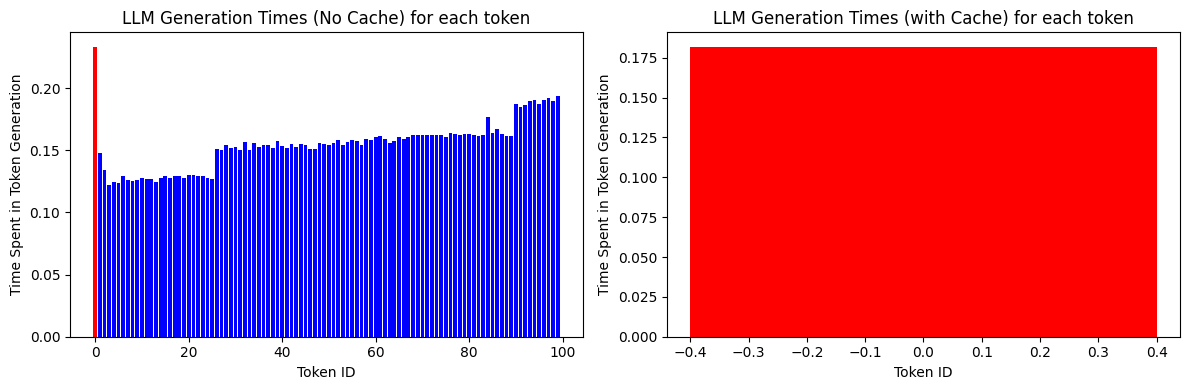

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Display the time cost of LLM token generation without KV Cache
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.bar(range(len(times)), times, color=['red'] + ['blue'] * (len(times) - 1))
plt.xlabel("Token ID")
plt.ylabel("Time Spent in Token Generation")
plt.title("LLM Generation Times (No Cache) for each token")


# Display the time cost of LLM token generation with KV Cache
plt.subplot(1, 2, 2)
plt.bar(range(len(times_with_cache)), times_with_cache, color=['red'] + ['blue'] * (len(times_with_cache) - 1))
plt.xlabel("Token ID")
plt.ylabel("Time Spent in Token Generation")
plt.title("LLM Generation Times (with Cache) for each token")

plt.tight_layout()
plt.show()